==================================================
RAČUNALNIŠKI VID – PREGLED TEM
==================================================

1. UVOD V RAČUNALNIŠKI VID
-------------------------
- računalniški vid vs. računalniška grafika
- področja uporabe


2. NASTANEK SLIKE IN OPTIKA
--------------------------
- camera obscura
- zaslonka (aperture)
- difrakcija
- dodana leča
- fokus
- krog negotovosti
- globinska ostrina


3. PROJEKCIJSKI MODEL KAMERE
----------------------------
- pinhole model
- projekcijsko središče (PS)
- projekcijska ravnina (PR)
- perspektivna projekcija
- ortografska projekcija
- afina / šibka perspektiva


4. HOMOGENE KOORDINATE
---------------------
- 2D homogene koordinate
- 3D homogene koordinate
- projektivne transformacije


5. TRANSFORMACIJE
-----------------
- evklidska transformacija
- podobnostna transformacija
- afina transformacija
- projektivna transformacija


6. MODEL KAMERE
---------------
- kalibracijska matrika K
- notranji parametri
- zunanji parametri
- projekcijska matrika M
- rotacijska matrika R
- vektor premika t


7. KALIBRACIJA KAMERE
--------------------
- šahovnica
- sistemi enačb
- SVD razcep
- najmanjše število točk
- radialna popačenja
- koeficienti popačenja


8. EPIPOLARNA GEOMETRIJA
-----------------------
- osnovnica (baseline)
- epipolarna ravnina
- epipolarna premica
- epipol
- epipolarna omejitev


9. MATRIKE MED POGLEDI
----------------------
- temeljna matrika F
- osnovna matrika E
- rang 2
- stopnje prostosti
- razmerje F–E


10. ISKANJE ZNAČILK IN UJEMANJE
------------------------------
- oglišča
- Harrisov detektor
- lastne vrednosti matrike Q


11. ROBUSTNA OCENA
-----------------
- RANSAC
- osamelci (outliers)
- kriterijska funkcija


12. PORAVNAVA SLIK
-----------------
- toga poravnava
- afina poravnava
- elastična poravnava
- intenzitetna poravnava (SSD)
- bilinearna interpolacija
- poravnava v frekvenčnem prostoru (FFT)

==================================================


==================================================
RAČUNALNIŠKI VID – PREGLED TEM
==================================================

1. UVOD V RAČUNALNIŠKI VID
-------------------------
- računalniški vid vs. računalniška grafika
- področja uporabe


2. NASTANEK SLIKE IN OPTIKA
--------------------------
- camera obscura
- zaslonka (aperture)
- difrakcija
- dodana leča
- fokus
- krog negotovosti
- globinska ostrina


3. PROJEKCIJSKI MODEL KAMERE
----------------------------
- pinhole model
- projekcijsko središče (PS)
- projekcijska ravnina (PR)
- perspektivna projekcija
- ortografska projekcija
- afina / šibka perspektiva


4. HOMOGENE KOORDINATE
---------------------
- 2D homogene koordinate
- 3D homogene koordinate
- projektivne transformacije


5. TRANSFORMACIJE
-----------------
- evklidska transformacija
- podobnostna transformacija
- afina transformacija
- projektivna transformacija


6. MODEL KAMERE
---------------
- kalibracijska matrika K
- notranji parametri
- zunanji parametri
- projekcijska matrika M
- rotacijska matrika R
- vektor premika t


7. KALIBRACIJA KAMERE
--------------------
- šahovnica
- sistemi enačb
- SVD razcep
- najmanjše število točk
- radialna popačenja
- koeficienti popačenja


8. EPIPOLARNA GEOMETRIJA
-----------------------
- osnovnica (baseline)
- epipolarna ravnina
- epipolarna premica
- epipol
- epipolarna omejitev


9. MATRIKE MED POGLEDI
----------------------
- temeljna matrika F
- osnovna matrika E
- rang 2
- stopnje prostosti
- razmerje F–E


10. ISKANJE ZNAČILK IN UJEMANJE
------------------------------
- oglišča
- Harrisov detektor
- lastne vrednosti matrike Q


11. ROBUSTNA OCENA
-----------------
- RANSAC
- osamelci (outliers)
- kriterijska funkcija


12. PORAVNAVA SLIK
-----------------
- toga poravnava
- afina poravnava
- elastična poravnava
- intenzitetna poravnava (SSD)
- bilinearna interpolacija
- poravnava v frekvenčnem prostoru (FFT)

==================================================


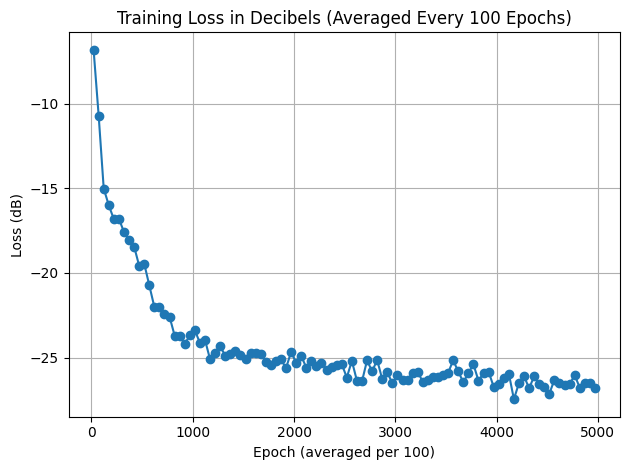

In [ ]:
import numpy as np
import math
import re
import matplotlib.pyplot as plt

# Paste your full log here as a triple-quoted string
log_text = """
Epoch 1/5000 - loss: 0.278712
Epoch 11/5000 - loss: 0.241942
Epoch 21/5000 - loss: 0.221625
Epoch 31/5000 - loss: 0.161623
Epoch 41/5000 - loss: 0.159543
Epoch 51/5000 - loss: 0.120179
Epoch 61/5000 - loss: 0.119663
Epoch 71/5000 - loss: 0.087152
Epoch 81/5000 - loss: 0.058846
Epoch 91/5000 - loss: 0.059735
Epoch 101/5000 - loss: 0.046074
Epoch 111/5000 - loss: 0.032030
Epoch 121/5000 - loss: 0.029752
Epoch 131/5000 - loss: 0.028105
Epoch 141/5000 - loss: 0.025021
Epoch 151/5000 - loss: 0.022777
Epoch 161/5000 - loss: 0.025277
Epoch 171/5000 - loss: 0.026371
Epoch 181/5000 - loss: 0.028398
Epoch 191/5000 - loss: 0.023041
Epoch 201/5000 - loss: 0.021891
Epoch 211/5000 - loss: 0.019984
Epoch 221/5000 - loss: 0.021836
Epoch 231/5000 - loss: 0.021914
Epoch 241/5000 - loss: 0.018359
Epoch 251/5000 - loss: 0.023814
Epoch 261/5000 - loss: 0.019033
Epoch 271/5000 - loss: 0.019683
Epoch 281/5000 - loss: 0.020577
Epoch 291/5000 - loss: 0.021698
Epoch 301/5000 - loss: 0.017321
Epoch 311/5000 - loss: 0.019858
Epoch 321/5000 - loss: 0.016775
Epoch 331/5000 - loss: 0.015794
Epoch 341/5000 - loss: 0.017639
Epoch 351/5000 - loss: 0.014137
Epoch 361/5000 - loss: 0.018574
Epoch 371/5000 - loss: 0.012916
Epoch 381/5000 - loss: 0.015300
Epoch 391/5000 - loss: 0.017861
Epoch 401/5000 - loss: 0.013696
Epoch 411/5000 - loss: 0.016988
Epoch 421/5000 - loss: 0.014124
Epoch 431/5000 - loss: 0.013592
Epoch 441/5000 - loss: 0.013485
Epoch 451/5000 - loss: 0.014201
Epoch 461/5000 - loss: 0.011905
Epoch 471/5000 - loss: 0.010106
Epoch 481/5000 - loss: 0.009329
Epoch 491/5000 - loss: 0.010198
Epoch 501/5000 - loss: 0.014012
Epoch 511/5000 - loss: 0.011048
Epoch 521/5000 - loss: 0.010321
Epoch 531/5000 - loss: 0.012465
Epoch 541/5000 - loss: 0.009389
Epoch 551/5000 - loss: 0.009748
Epoch 561/5000 - loss: 0.007539
Epoch 571/5000 - loss: 0.008812
Epoch 581/5000 - loss: 0.008493
Epoch 591/5000 - loss: 0.007797
Epoch 601/5000 - loss: 0.006447
Epoch 611/5000 - loss: 0.005908
Epoch 621/5000 - loss: 0.007011
Epoch 631/5000 - loss: 0.005448
Epoch 641/5000 - loss: 0.006777
Epoch 651/5000 - loss: 0.005905
Epoch 661/5000 - loss: 0.006435
Epoch 671/5000 - loss: 0.006945
Epoch 681/5000 - loss: 0.008235
Epoch 691/5000 - loss: 0.004686
Epoch 701/5000 - loss: 0.005575
Epoch 711/5000 - loss: 0.005637
Epoch 721/5000 - loss: 0.007612
Epoch 731/5000 - loss: 0.005272
Epoch 741/5000 - loss: 0.004750
Epoch 751/5000 - loss: 0.005549
Epoch 761/5000 - loss: 0.005689
Epoch 771/5000 - loss: 0.007574
Epoch 781/5000 - loss: 0.004936
Epoch 791/5000 - loss: 0.004311
Epoch 801/5000 - loss: 0.004314
Epoch 811/5000 - loss: 0.003949
Epoch 821/5000 - loss: 0.004002
Epoch 831/5000 - loss: 0.004150
Epoch 841/5000 - loss: 0.005018
Epoch 851/5000 - loss: 0.004067
Epoch 861/5000 - loss: 0.005076
Epoch 871/5000 - loss: 0.004413
Epoch 881/5000 - loss: 0.003576
Epoch 891/5000 - loss: 0.004077
Epoch 901/5000 - loss: 0.003908
Epoch 911/5000 - loss: 0.003983
Epoch 921/5000 - loss: 0.003740
Epoch 931/5000 - loss: 0.003368
Epoch 941/5000 - loss: 0.004110
Epoch 951/5000 - loss: 0.004216
Epoch 961/5000 - loss: 0.004223
Epoch 971/5000 - loss: 0.004229
Epoch 981/5000 - loss: 0.003742
Epoch 991/5000 - loss: 0.005047
Epoch 1001/5000 - loss: 0.005241
Epoch 1011/5000 - loss: 0.004358
Epoch 1021/5000 - loss: 0.003811
Epoch 1031/5000 - loss: 0.005072
Epoch 1041/5000 - loss: 0.004596
Epoch 1051/5000 - loss: 0.004976
Epoch 1061/5000 - loss: 0.004209
Epoch 1071/5000 - loss: 0.003434
Epoch 1081/5000 - loss: 0.003330
Epoch 1091/5000 - loss: 0.003552
Epoch 1101/5000 - loss: 0.003969
Epoch 1111/5000 - loss: 0.003657
Epoch 1121/5000 - loss: 0.004760
Epoch 1131/5000 - loss: 0.004613
Epoch 1141/5000 - loss: 0.003307
Epoch 1151/5000 - loss: 0.003436
Epoch 1161/5000 - loss: 0.002716
Epoch 1171/5000 - loss: 0.002831
Epoch 1181/5000 - loss: 0.003525
Epoch 1191/5000 - loss: 0.003024
Epoch 1201/5000 - loss: 0.003648
Epoch 1211/5000 - loss: 0.003545
Epoch 1221/5000 - loss: 0.003378
Epoch 1231/5000 - loss: 0.003095
Epoch 1241/5000 - loss: 0.003114
Epoch 1251/5000 - loss: 0.005499
Epoch 1261/5000 - loss: 0.003894
Epoch 1271/5000 - loss: 0.003757
Epoch 1281/5000 - loss: 0.003664
Epoch 1291/5000 - loss: 0.002304
Epoch 1301/5000 - loss: 0.003166
Epoch 1311/5000 - loss: 0.002760
Epoch 1321/5000 - loss: 0.003290
Epoch 1331/5000 - loss: 0.003784
Epoch 1341/5000 - loss: 0.003333
Epoch 1351/5000 - loss: 0.002862
Epoch 1361/5000 - loss: 0.003045
Epoch 1371/5000 - loss: 0.003699
Epoch 1381/5000 - loss: 0.004282
Epoch 1391/5000 - loss: 0.003012
Epoch 1401/5000 - loss: 0.003472
Epoch 1411/5000 - loss: 0.003397
Epoch 1421/5000 - loss: 0.003670
Epoch 1431/5000 - loss: 0.003339
Epoch 1441/5000 - loss: 0.003453
Epoch 1451/5000 - loss: 0.002755
Epoch 1461/5000 - loss: 0.003605
Epoch 1471/5000 - loss: 0.003603
Epoch 1481/5000 - loss: 0.003249
Epoch 1491/5000 - loss: 0.003352
Epoch 1501/5000 - loss: 0.004090
Epoch 1511/5000 - loss: 0.002488
Epoch 1521/5000 - loss: 0.003438
Epoch 1531/5000 - loss: 0.002739
Epoch 1541/5000 - loss: 0.003075
Epoch 1551/5000 - loss: 0.003571
Epoch 1561/5000 - loss: 0.003639
Epoch 1571/5000 - loss: 0.003009
Epoch 1581/5000 - loss: 0.004145
Epoch 1591/5000 - loss: 0.002613
Epoch 1601/5000 - loss: 0.003271
Epoch 1611/5000 - loss: 0.003370
Epoch 1621/5000 - loss: 0.003002
Epoch 1631/5000 - loss: 0.004047
Epoch 1641/5000 - loss: 0.003150
Epoch 1651/5000 - loss: 0.002764
Epoch 1661/5000 - loss: 0.003246
Epoch 1671/5000 - loss: 0.003260
Epoch 1681/5000 - loss: 0.003633
Epoch 1691/5000 - loss: 0.003824
Epoch 1701/5000 - loss: 0.003097
Epoch 1711/5000 - loss: 0.003058
Epoch 1721/5000 - loss: 0.003062
Epoch 1731/5000 - loss: 0.003436
Epoch 1741/5000 - loss: 0.002408
Epoch 1751/5000 - loss: 0.002662
Epoch 1761/5000 - loss: 0.003183
Epoch 1771/5000 - loss: 0.003009
Epoch 1781/5000 - loss: 0.002575
Epoch 1791/5000 - loss: 0.002937
Epoch 1801/5000 - loss: 0.002969
Epoch 1811/5000 - loss: 0.002422
Epoch 1821/5000 - loss: 0.003765
Epoch 1831/5000 - loss: 0.003270
Epoch 1841/5000 - loss: 0.002903
Epoch 1851/5000 - loss: 0.003437
Epoch 1861/5000 - loss: 0.002946
Epoch 1871/5000 - loss: 0.003312
Epoch 1881/5000 - loss: 0.002801
Epoch 1891/5000 - loss: 0.003019
Epoch 1901/5000 - loss: 0.002276
Epoch 1911/5000 - loss: 0.003291
Epoch 1921/5000 - loss: 0.003538
Epoch 1931/5000 - loss: 0.001851
Epoch 1941/5000 - loss: 0.003146
Epoch 1951/5000 - loss: 0.004208
Epoch 1961/5000 - loss: 0.002899
Epoch 1971/5000 - loss: 0.003382
Epoch 1981/5000 - loss: 0.003298
Epoch 1991/5000 - loss: 0.003418
Epoch 2001/5000 - loss: 0.003301
Epoch 2011/5000 - loss: 0.003049
Epoch 2021/5000 - loss: 0.002766
Epoch 2031/5000 - loss: 0.003010
Epoch 2041/5000 - loss: 0.002631
Epoch 2051/5000 - loss: 0.003287
Epoch 2061/5000 - loss: 0.003182
Epoch 2071/5000 - loss: 0.003285
Epoch 2081/5000 - loss: 0.003357
Epoch 2091/5000 - loss: 0.003079
Epoch 2101/5000 - loss: 0.003404
Epoch 2111/5000 - loss: 0.002411
Epoch 2121/5000 - loss: 0.002983
Epoch 2131/5000 - loss: 0.002429
Epoch 2141/5000 - loss: 0.002706
Epoch 2151/5000 - loss: 0.003343
Epoch 2161/5000 - loss: 0.002390
Epoch 2171/5000 - loss: 0.002957
Epoch 2181/5000 - loss: 0.003494
Epoch 2191/5000 - loss: 0.003130
Epoch 2201/5000 - loss: 0.003050
Epoch 2211/5000 - loss: 0.002636
Epoch 2221/5000 - loss: 0.002727
Epoch 2231/5000 - loss: 0.002373
Epoch 2241/5000 - loss: 0.003460
Epoch 2251/5000 - loss: 0.003685
Epoch 2261/5000 - loss: 0.003135
Epoch 2271/5000 - loss: 0.002878
Epoch 2281/5000 - loss: 0.003097
Epoch 2291/5000 - loss: 0.002108
Epoch 2301/5000 - loss: 0.003095
Epoch 2311/5000 - loss: 0.002881
Epoch 2321/5000 - loss: 0.003290
Epoch 2331/5000 - loss: 0.002025
Epoch 2341/5000 - loss: 0.002372
Epoch 2351/5000 - loss: 0.003325
Epoch 2361/5000 - loss: 0.003018
Epoch 2371/5000 - loss: 0.001878
Epoch 2381/5000 - loss: 0.002608
Epoch 2391/5000 - loss: 0.003438
Epoch 2401/5000 - loss: 0.002865
Epoch 2411/5000 - loss: 0.002439
Epoch 2421/5000 - loss: 0.002761
Epoch 2431/5000 - loss: 0.003056
Epoch 2441/5000 - loss: 0.003147
Epoch 2451/5000 - loss: 0.002383
Epoch 2461/5000 - loss: 0.003407
Epoch 2471/5000 - loss: 0.002853
Epoch 2481/5000 - loss: 0.002547
Epoch 2491/5000 - loss: 0.003462
Epoch 2501/5000 - loss: 0.002255
Epoch 2511/5000 - loss: 0.002870
Epoch 2521/5000 - loss: 0.002238
Epoch 2531/5000 - loss: 0.001981
Epoch 2541/5000 - loss: 0.002847
Epoch 2551/5000 - loss: 0.003560
Epoch 2561/5000 - loss: 0.002919
Epoch 2571/5000 - loss: 0.003081
Epoch 2581/5000 - loss: 0.002617
Epoch 2591/5000 - loss: 0.003018
Epoch 2601/5000 - loss: 0.002439
Epoch 2611/5000 - loss: 0.002471
Epoch 2621/5000 - loss: 0.002577
Epoch 2631/5000 - loss: 0.002088
Epoch 2641/5000 - loss: 0.002027
Epoch 2651/5000 - loss: 0.002481
Epoch 2661/5000 - loss: 0.002086
Epoch 2671/5000 - loss: 0.002356
Epoch 2681/5000 - loss: 0.002299
Epoch 2691/5000 - loss: 0.002248
Epoch 2701/5000 - loss: 0.002960
Epoch 2711/5000 - loss: 0.003437
Epoch 2721/5000 - loss: 0.002737
Epoch 2731/5000 - loss: 0.003378
Epoch 2741/5000 - loss: 0.002783
Epoch 2751/5000 - loss: 0.003051
Epoch 2761/5000 - loss: 0.002974
Epoch 2771/5000 - loss: 0.002408
Epoch 2781/5000 - loss: 0.002472
Epoch 2791/5000 - loss: 0.002311
Epoch 2801/5000 - loss: 0.003691
Epoch 2811/5000 - loss: 0.002369
Epoch 2821/5000 - loss: 0.003572
Epoch 2831/5000 - loss: 0.003168
Epoch 2841/5000 - loss: 0.002714
Epoch 2851/5000 - loss: 0.002591
Epoch 2861/5000 - loss: 0.001911
Epoch 2871/5000 - loss: 0.002504
Epoch 2881/5000 - loss: 0.002968
Epoch 2891/5000 - loss: 0.001968
Epoch 2901/5000 - loss: 0.002646
Epoch 2911/5000 - loss: 0.001956
Epoch 2921/5000 - loss: 0.003079
Epoch 2931/5000 - loss: 0.002949
Epoch 2941/5000 - loss: 0.002505
Epoch 2951/5000 - loss: 0.001676
Epoch 2961/5000 - loss: 0.002258
Epoch 2971/5000 - loss: 0.002849
Epoch 2981/5000 - loss: 0.002407
Epoch 2991/5000 - loss: 0.002115
Epoch 3001/5000 - loss: 0.002117
Epoch 3011/5000 - loss: 0.003020
Epoch 3021/5000 - loss: 0.002817
Epoch 3031/5000 - loss: 0.001829
Epoch 3041/5000 - loss: 0.002852
Epoch 3051/5000 - loss: 0.002823
Epoch 3061/5000 - loss: 0.001779
Epoch 3071/5000 - loss: 0.002565
Epoch 3081/5000 - loss: 0.002502
Epoch 3091/5000 - loss: 0.002108
Epoch 3101/5000 - loss: 0.002079
Epoch 3111/5000 - loss: 0.002573
Epoch 3121/5000 - loss: 0.002192
Epoch 3131/5000 - loss: 0.001774
Epoch 3141/5000 - loss: 0.003209
Epoch 3151/5000 - loss: 0.002594
Epoch 3161/5000 - loss: 0.003287
Epoch 3171/5000 - loss: 0.002178
Epoch 3181/5000 - loss: 0.001897
Epoch 3191/5000 - loss: 0.003175
Epoch 3201/5000 - loss: 0.002712
Epoch 3211/5000 - loss: 0.002467
Epoch 3221/5000 - loss: 0.002460
Epoch 3231/5000 - loss: 0.002490
Epoch 3241/5000 - loss: 0.003001
Epoch 3251/5000 - loss: 0.002036
Epoch 3261/5000 - loss: 0.001843
Epoch 3271/5000 - loss: 0.002518
Epoch 3281/5000 - loss: 0.002167
Epoch 3291/5000 - loss: 0.002956
Epoch 3301/5000 - loss: 0.003011
Epoch 3311/5000 - loss: 0.001965
Epoch 3321/5000 - loss: 0.002556
Epoch 3331/5000 - loss: 0.002400
Epoch 3341/5000 - loss: 0.001887
Epoch 3351/5000 - loss: 0.003347
Epoch 3361/5000 - loss: 0.003420
Epoch 3371/5000 - loss: 0.001719
Epoch 3381/5000 - loss: 0.002065
Epoch 3391/5000 - loss: 0.002064
Epoch 3401/5000 - loss: 0.002341
Epoch 3411/5000 - loss: 0.003334
Epoch 3421/5000 - loss: 0.002419
Epoch 3431/5000 - loss: 0.002084
Epoch 3441/5000 - loss: 0.002163
Epoch 3451/5000 - loss: 0.002398
Epoch 3461/5000 - loss: 0.001917
Epoch 3471/5000 - loss: 0.002157
Epoch 3481/5000 - loss: 0.003407
Epoch 3491/5000 - loss: 0.002853
Epoch 3501/5000 - loss: 0.002470
Epoch 3511/5000 - loss: 0.002588
Epoch 3521/5000 - loss: 0.002308
Epoch 3531/5000 - loss: 0.002580
Epoch 3541/5000 - loss: 0.002922
Epoch 3551/5000 - loss: 0.002668
Epoch 3561/5000 - loss: 0.002753
Epoch 3571/5000 - loss: 0.003772
Epoch 3581/5000 - loss: 0.003017
Epoch 3591/5000 - loss: 0.003137
Epoch 3601/5000 - loss: 0.003022
Epoch 3611/5000 - loss: 0.002463
Epoch 3621/5000 - loss: 0.002628
Epoch 3631/5000 - loss: 0.002438
Epoch 3641/5000 - loss: 0.002626
Epoch 3651/5000 - loss: 0.002384
Epoch 3661/5000 - loss: 0.002383
Epoch 3671/5000 - loss: 0.001862
Epoch 3681/5000 - loss: 0.001665
Epoch 3691/5000 - loss: 0.003369
Epoch 3701/5000 - loss: 0.002677
Epoch 3711/5000 - loss: 0.002268
Epoch 3721/5000 - loss: 0.003062
Epoch 3731/5000 - loss: 0.002482
Epoch 3741/5000 - loss: 0.002340
Epoch 3751/5000 - loss: 0.002364
Epoch 3761/5000 - loss: 0.003243
Epoch 3771/5000 - loss: 0.002923
Epoch 3781/5000 - loss: 0.002631
Epoch 3791/5000 - loss: 0.003435
Epoch 3801/5000 - loss: 0.002004
Epoch 3811/5000 - loss: 0.002821
Epoch 3821/5000 - loss: 0.002212
Epoch 3831/5000 - loss: 0.002298
Epoch 3841/5000 - loss: 0.002282
Epoch 3851/5000 - loss: 0.002764
Epoch 3861/5000 - loss: 0.002568
Epoch 3871/5000 - loss: 0.002010
Epoch 3881/5000 - loss: 0.004050
Epoch 3891/5000 - loss: 0.001901
Epoch 3901/5000 - loss: 0.001990
Epoch 3911/5000 - loss: 0.003436
Epoch 3921/5000 - loss: 0.002450
Epoch 3931/5000 - loss: 0.002867
Epoch 3941/5000 - loss: 0.002530
Epoch 3951/5000 - loss: 0.002147
Epoch 3961/5000 - loss: 0.002137
Epoch 3971/5000 - loss: 0.002252
Epoch 3981/5000 - loss: 0.002020
Epoch 3991/5000 - loss: 0.002093
Epoch 4001/5000 - loss: 0.001861
Epoch 4011/5000 - loss: 0.002290
Epoch 4021/5000 - loss: 0.002110
Epoch 4031/5000 - loss: 0.002426
Epoch 4041/5000 - loss: 0.002435
Epoch 4051/5000 - loss: 0.002240
Epoch 4061/5000 - loss: 0.002242
Epoch 4071/5000 - loss: 0.002467
Epoch 4081/5000 - loss: 0.002123
Epoch 4091/5000 - loss: 0.002928
Epoch 4101/5000 - loss: 0.003600
Epoch 4111/5000 - loss: 0.002392
Epoch 4121/5000 - loss: 0.002276
Epoch 4131/5000 - loss: 0.002157
Epoch 4141/5000 - loss: 0.002519
Epoch 4151/5000 - loss: 0.002395
Epoch 4161/5000 - loss: 0.001397
Epoch 4171/5000 - loss: 0.002170
Epoch 4181/5000 - loss: 0.001099
Epoch 4191/5000 - loss: 0.002339
Epoch 4201/5000 - loss: 0.002741
Epoch 4211/5000 - loss: 0.002470
Epoch 4221/5000 - loss: 0.002111
Epoch 4231/5000 - loss: 0.002355
Epoch 4241/5000 - loss: 0.001675
Epoch 4251/5000 - loss: 0.003072
Epoch 4261/5000 - loss: 0.002032
Epoch 4271/5000 - loss: 0.002322
Epoch 4281/5000 - loss: 0.002682
Epoch 4291/5000 - loss: 0.002312
Epoch 4301/5000 - loss: 0.002323
Epoch 4311/5000 - loss: 0.001754
Epoch 4321/5000 - loss: 0.002152
Epoch 4331/5000 - loss: 0.002065
Epoch 4341/5000 - loss: 0.002163
Epoch 4351/5000 - loss: 0.002467
Epoch 4361/5000 - loss: 0.002015
Epoch 4371/5000 - loss: 0.002223
Epoch 4381/5000 - loss: 0.002916
Epoch 4391/5000 - loss: 0.002769
Epoch 4401/5000 - loss: 0.002089
Epoch 4411/5000 - loss: 0.002492
Epoch 4421/5000 - loss: 0.002717
Epoch 4431/5000 - loss: 0.002493
Epoch 4441/5000 - loss: 0.001458
Epoch 4451/5000 - loss: 0.001672
Epoch 4461/5000 - loss: 0.002645
Epoch 4471/5000 - loss: 0.002136
Epoch 4481/5000 - loss: 0.001761
Epoch 4491/5000 - loss: 0.002497
Epoch 4501/5000 - loss: 0.002054
Epoch 4511/5000 - loss: 0.002266
Epoch 4521/5000 - loss: 0.002103
Epoch 4531/5000 - loss: 0.001671
Epoch 4541/5000 - loss: 0.001670
Epoch 4551/5000 - loss: 0.002401
Epoch 4561/5000 - loss: 0.002423
Epoch 4571/5000 - loss: 0.002567
Epoch 4581/5000 - loss: 0.002517
Epoch 4591/5000 - loss: 0.001866
Epoch 4601/5000 - loss: 0.002489
Epoch 4611/5000 - loss: 0.002752
Epoch 4621/5000 - loss: 0.001828
Epoch 4631/5000 - loss: 0.002557
Epoch 4641/5000 - loss: 0.001800
Epoch 4651/5000 - loss: 0.002546
Epoch 4661/5000 - loss: 0.002681
Epoch 4671/5000 - loss: 0.001861
Epoch 4681/5000 - loss: 0.001903
Epoch 4691/5000 - loss: 0.001969
Epoch 4701/5000 - loss: 0.003229
Epoch 4711/5000 - loss: 0.001779
Epoch 4721/5000 - loss: 0.001901
Epoch 4731/5000 - loss: 0.002469
Epoch 4741/5000 - loss: 0.001920
Epoch 4751/5000 - loss: 0.002520
Epoch 4761/5000 - loss: 0.001631
Epoch 4771/5000 - loss: 0.003091
Epoch 4781/5000 - loss: 0.003030
Epoch 4791/5000 - loss: 0.002499
Epoch 4801/5000 - loss: 0.002534
Epoch 4811/5000 - loss: 0.002174
Epoch 4821/5000 - loss: 0.001805
Epoch 4831/5000 - loss: 0.002739
Epoch 4841/5000 - loss: 0.001501
Epoch 4851/5000 - loss: 0.002064
Epoch 4861/5000 - loss: 0.002455
Epoch 4871/5000 - loss: 0.001882
Epoch 4881/5000 - loss: 0.002213
Epoch 4891/5000 - loss: 0.002708
Epoch 4901/5000 - loss: 0.001977
Epoch 4911/5000 - loss: 0.001867
Epoch 4921/5000 - loss: 0.002079
Epoch 4931/5000 - loss: 0.002237
Epoch 4941/5000 - loss: 0.003221
Epoch 4951/5000 - loss: 0.001992
Epoch 4961/5000 - loss: 0.002729
Epoch 4971/5000 - loss: 0.001897
Epoch 4981/5000 - loss: 0.002144
Epoch 4991/5000 - loss: 0.001811"""


epochs = []
losses = []

for line in log_text.splitlines():
    m = re.search(r"Epoch\s+(\d+)/\d+\s+- loss:\s+([0-9.]+)", line)
    if m:
        epochs.append(int(m.group(1)))
        losses.append(float(m.group(2)))

# --- Convert to dB ---
losses_db = np.array([10 * math.log10(l) for l in losses])
epochs = np.array(epochs)

# --- Average every 100 epochs ---
window =10

avg_epochs = []
avg_losses_db = []

for start in range(0, len(losses_db), window):
    end = start + window
    avg_losses_db.append(np.mean(losses_db[start:end]))
    avg_epochs.append(np.mean(epochs[start:end]))

# --- Plot averaged values ---
plt.plot(avg_epochs, avg_losses_db, marker='o')
plt.xlabel("Epoch (averaged per 100)")
plt.ylabel("Loss (dB)")
plt.title("Training Loss in Decibels (Averaged Every 100 Epochs)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
import kagglehub
import shutil
import os

# Download
path = kagglehub.dataset_download("ll01dm/t91-image-dataset")

# Target directory
target = "./T91"

# Create target if it doesn't exist
os.makedirs(target, exist_ok=True)

# Move files
shutil.copytree(path, target, dirs_exist_ok=True)

print("Dataset is now in:", os.path.abspath(target))


/Users/stefansrjakovferi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/stefansrjakovferi/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset is now in: /Users/stefansrjakovferi/predmeti/third-semester/NaprednaObdelavaSlik/Vaja2/T91


In [10]:
import os

print("Download path:", path)
print("Contents:", os.listdir(path))


Download path: /Users/stefansrjakovferi/.cache/kagglehub/datasets/ll01dm/t91-image-dataset/versions/1
Contents: []


In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ll01dm/t91-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/stefansrjakovferi/.cache/kagglehub/datasets/ll01dm/t91-image-dataset/versions/1


In [ ]:
from datasets import load_dataset
import os
import shutil

# Load dataset (this downloads it into HF cache)
ds = load_dataset("Voxel51/Set5")

# Destination directory
target_dir = "./test"
os.makedirs(target_dir, exist_ok=True)

# Find HF cache directory
cache_dir = ds.cache_files[0]['filename']
base_dir = os.path.dirname(cache_dir)

print("Cache location:", base_dir)

# Copy all files into ./test
for root, dirs, files in os.walk(base_dir):
    for file in files:
        src = os.path.join(root, file)
        shutil.copy2(src, target_dir)

print("Copied files into:", target_dir)
print("Final files:", os.listdir(target_dir))


SyntaxError: unexpected EOF while parsing (3038374251.py, line 19)